<a href="https://colab.research.google.com/github/MaksimDar/matrix_ai/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22codewomen_pytorch_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Based on the [PyTorch quickstart tutorial](https://docs.pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html).

## Setup

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

## Data

Check out different options for datasets here: https://docs.pytorch.org/vision/main/datasets.html

In [ ]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 519kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.63MB/s]


In [ ]:
batch_size = 64

In [ ]:
# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

In [ ]:
for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


## Defining model


In [ ]:
#device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device = 'cpu'
print(f"Using {device} device")

Using cpu device


Some things are missing in the class below! Complete them :)

In [ ]:
# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.Linear(512, 512),
            nn.Linear(512,10)
        )

    def forward(self, x):
      x = self.flatten(x)
      logits = self.linear_relu_stack(x)
      return logits

In [ ]:
model = NeuralNetwork().to(device)

In [ ]:
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): Linear(in_features=512, out_features=10, bias=True)
  )
)


## Training model

Some things are missing below! Complete them :)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

Some things are missing in the function below! Complete them :)

In [ ]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        # Missing things here
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

In [ ]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

Here recall epochs and mini batches:

In [ ]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.301382  [   64/60000]
loss: 2.278028  [ 6464/60000]
loss: 2.255676  [12864/60000]
loss: 2.212097  [19264/60000]
loss: 2.194118  [25664/60000]
loss: 2.174531  [32064/60000]
loss: 2.143753  [38464/60000]
loss: 2.144472  [44864/60000]
loss: 2.076539  [51264/60000]
loss: 2.049776  [57664/60000]
Test Error: 
 Accuracy: 71.2%, Avg loss: 2.035773 

Epoch 2
-------------------------------
loss: 2.033798  [   64/60000]
loss: 1.997207  [ 6464/60000]
loss: 2.015566  [12864/60000]
loss: 1.887901  [19264/60000]
loss: 1.898161  [25664/60000]
loss: 1.878132  [32064/60000]
loss: 1.817955  [38464/60000]
loss: 1.865025  [44864/60000]
loss: 1.745708  [51264/60000]
loss: 1.700152  [57664/60000]
Test Error: 
 Accuracy: 75.3%, Avg loss: 1.678650 

Epoch 3
-------------------------------
loss: 1.685498  [   64/60000]
loss: 1.613743  [ 6464/60000]
loss: 1.670469  [12864/60000]
loss: 1.486750  [19264/60000]
loss: 1.492634  [25664/60000]
loss: 1.472624  [32064/600

## Saving your model

In [ ]:
torch.save(model.state_dict(), "model.pth")
print("Saved PyTorch Model State to model.pth")

Saved PyTorch Model State to model.pth


## Loading model and using it

In [ ]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model.pth", weights_only=True))

<All keys matched successfully>

In [ ]:
classes = [0,1,2,3,4,5,6,7,8,9]

In [ ]:
for i in range(20):
    model.eval()
    x, y = test_data[i][0], test_data[i][1]
    with torch.no_grad():
        x = x.to(device)
        pred = model(x)
        predicted, actual = classes[pred[0].argmax(0)], classes[y]
        print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "7", Actual: "7"
Predicted: "2", Actual: "2"
Predicted: "1", Actual: "1"
Predicted: "0", Actual: "0"
Predicted: "4", Actual: "4"
Predicted: "1", Actual: "1"
Predicted: "4", Actual: "4"
Predicted: "9", Actual: "9"
Predicted: "6", Actual: "5"
Predicted: "9", Actual: "9"
Predicted: "0", Actual: "0"
Predicted: "6", Actual: "6"
Predicted: "9", Actual: "9"
Predicted: "0", Actual: "0"
Predicted: "1", Actual: "1"
Predicted: "3", Actual: "5"
Predicted: "9", Actual: "9"
Predicted: "7", Actual: "7"
Predicted: "3", Actual: "3"
Predicted: "4", Actual: "4"


## Quick look at confusion matrix

Useful tool from scikit learn to look at model performance

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
test_labels = []
test_preds = []

with torch.no_grad():
    for X, y in test_data:
        pred = model(X)
        test_preds.append(classes[pred[0].argmax(0)])
        test_labels.append(y)

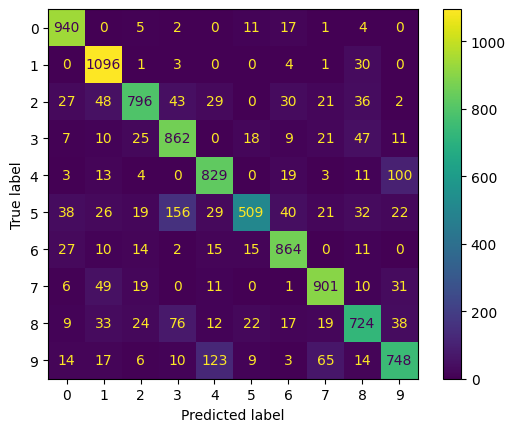

In [ ]:
cm = confusion_matrix(test_labels, test_preds)
ConfusionMatrixDisplay(cm).plot()

Can you tell for which numbers the model performed better or worse?

**Take home message**: you can reuse this structure, and change some parts according to the problem you're trying to solve